In [1]:
import pandas as pd

df = pd.read_csv("data/EMS_Incident_Dispatch_Data.csv")

In [2]:
df.shape

(4855843, 31)

In [4]:
df.head()

,INCIDENT_ID,INCIDENT_DATETIME,INITIAL_CALL_TYPE,INITIAL_SEVERITY_LEVEL_CODE,FINAL_CALL_TYPE,FINAL_SEVERITY_LEVEL_CODE,FIRST_ASSIGNMENT_DATETIME,VALID_DISPATCH_RSPNS_TIME_INDC,DISPATCH_RESPONSE_SECONDS_QY,FIRST_ACTIVATION_DATETIME,...,ZIPCODE,POLICEPRECINCT,CITYCOUNCILDISTRICT,COMMUNITYDISTRICT,COMMUNITYSCHOOLDISTRICT,CONGRESSIONALDISTRICT,REOPEN_INDICATOR,SPECIAL_EVENT_INDICATOR,STANDBY_INDICATOR,TRANSFER_INDICATOR
0,76520399,01/01/2023 03:24:06 PM,DRUGFC,4,DRUGFC,4,01/01/2023 03:24:46 PM,Y,40,01/01/2023 03:25:24 PM,...,10460.0,48.0,17.0,206.0,12.0,15.0,N,N,N,N
1,76520400,01/01/2023 03:25:08 PM,INJURY,5,INJURY,5,01/01/2023 03:25:23 PM,Y,15,01/01/2023 03:25:33 PM,...,11233.0,73.0,37.0,316.0,23.0,8.0,N,N,N,N
2,76520401,01/01/2023 03:25:18 PM,CDBRFC,2,CDBRFC,2,01/01/2023 03:25:24 PM,Y,6,01/01/2023 03:25:59 PM,...,11377.0,108.0,26.0,402.0,24.0,14.0,N,N,N,N
3,76520402,01/01/2023 03:25:27 PM,SICK,6,SICK,6,01/01/2023 03:43:50 PM,Y,"1,103",01/01/2023 03:44:56 PM,...,11226.0,70.0,40.0,314.0,22.0,9.0,N,N,N,N
4,76520403,01/01/2023 03:25:29 PM,CARDFC,3,CARDFC,3,01/01/2023 03:26:16 PM,Y,47,01/01/2023 03:26:30 PM,...,10029.0,23.0,8.0,111.0,4.0,13.0,N,N,N,N


In [9]:
# Clean version — fixes the CopyWarning properly
df = df[['INCIDENT_DATETIME', 'INITIAL_CALL_TYPE', 'INITIAL_SEVERITY_LEVEL_CODE', 'BOROUGH']].copy()

# Parse datetime
df['INCIDENT_DATETIME'] = pd.to_datetime(df['INCIDENT_DATETIME'], infer_datetime_format=True)

# Extract date
df['DATE'] = df['INCIDENT_DATETIME'].dt.date

# Check results
print("Shape:", df.shape)
print("\nNull values:\n", df.isnull().sum())
print("\nSample:\n", df.head())

C:\Users\rohit\AppData\Local\Temp\ipykernel_23896\930845392.py:5: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['INCIDENT_DATETIME'] = pd.to_datetime(df['INCIDENT_DATETIME'], infer_datetime_format=True)


Shape: (4855843, 5)

Null values:
 INCIDENT_DATETIME              0
INITIAL_CALL_TYPE              0
INITIAL_SEVERITY_LEVEL_CODE    0
BOROUGH                        0
DATE                           0
dtype: int64

Sample:
     INCIDENT_DATETIME INITIAL_CALL_TYPE  INITIAL_SEVERITY_LEVEL_CODE  \
0 2023-01-01 15:24:06            DRUGFC                            4   
1 2023-01-01 15:25:08            INJURY                            5   
2 2023-01-01 15:25:18            CDBRFC                            2   
3 2023-01-01 15:25:27              SICK                            6   
4 2023-01-01 15:25:29            CARDFC                            3   

     BOROUGH        DATE  
0      BRONX  2023-01-01  
1   BROOKLYN  2023-01-01  
2     QUEENS  2023-01-01  
3   BROOKLYN  2023-01-01  
4  MANHATTAN  2023-01-01  


In [10]:
# Step 2 — Aggregate to daily incident counts
daily_df = df.groupby('DATE').size().reset_index(name='INCIDENT_COUNT')

# Convert DATE to datetime for time series
daily_df['DATE'] = pd.to_datetime(daily_df['DATE'])

# Sort by date
daily_df = daily_df.sort_values('DATE').reset_index(drop=True)

# Check
print("Shape:", daily_df.shape)
print("\nDate range:", daily_df['DATE'].min(), "to", daily_df['DATE'].max())
print("\nDaily stats:\n", daily_df['INCIDENT_COUNT'].describe())
print("\nSample:\n", daily_df.head(10))

Shape: (1096, 2)

Date range: 2023-01-01 00:00:00 to 2025-12-31 00:00:00

Daily stats:
 count    1096.000000
mean     4430.513686
std       287.060994
min      1939.000000
25%      4260.000000
50%      4449.500000
75%      4607.250000
max      5502.000000
Name: INCIDENT_COUNT, dtype: float64

Sample:
         DATE  INCIDENT_COUNT
0 2023-01-01            1939
1 2023-01-02            4384
2 2023-01-03            4711
3 2023-01-04            4788
4 2023-01-05            4528
5 2023-01-06            4476
6 2023-01-07            4007
7 2023-01-08            3825
8 2023-01-09            4249
9 2023-01-10            4220


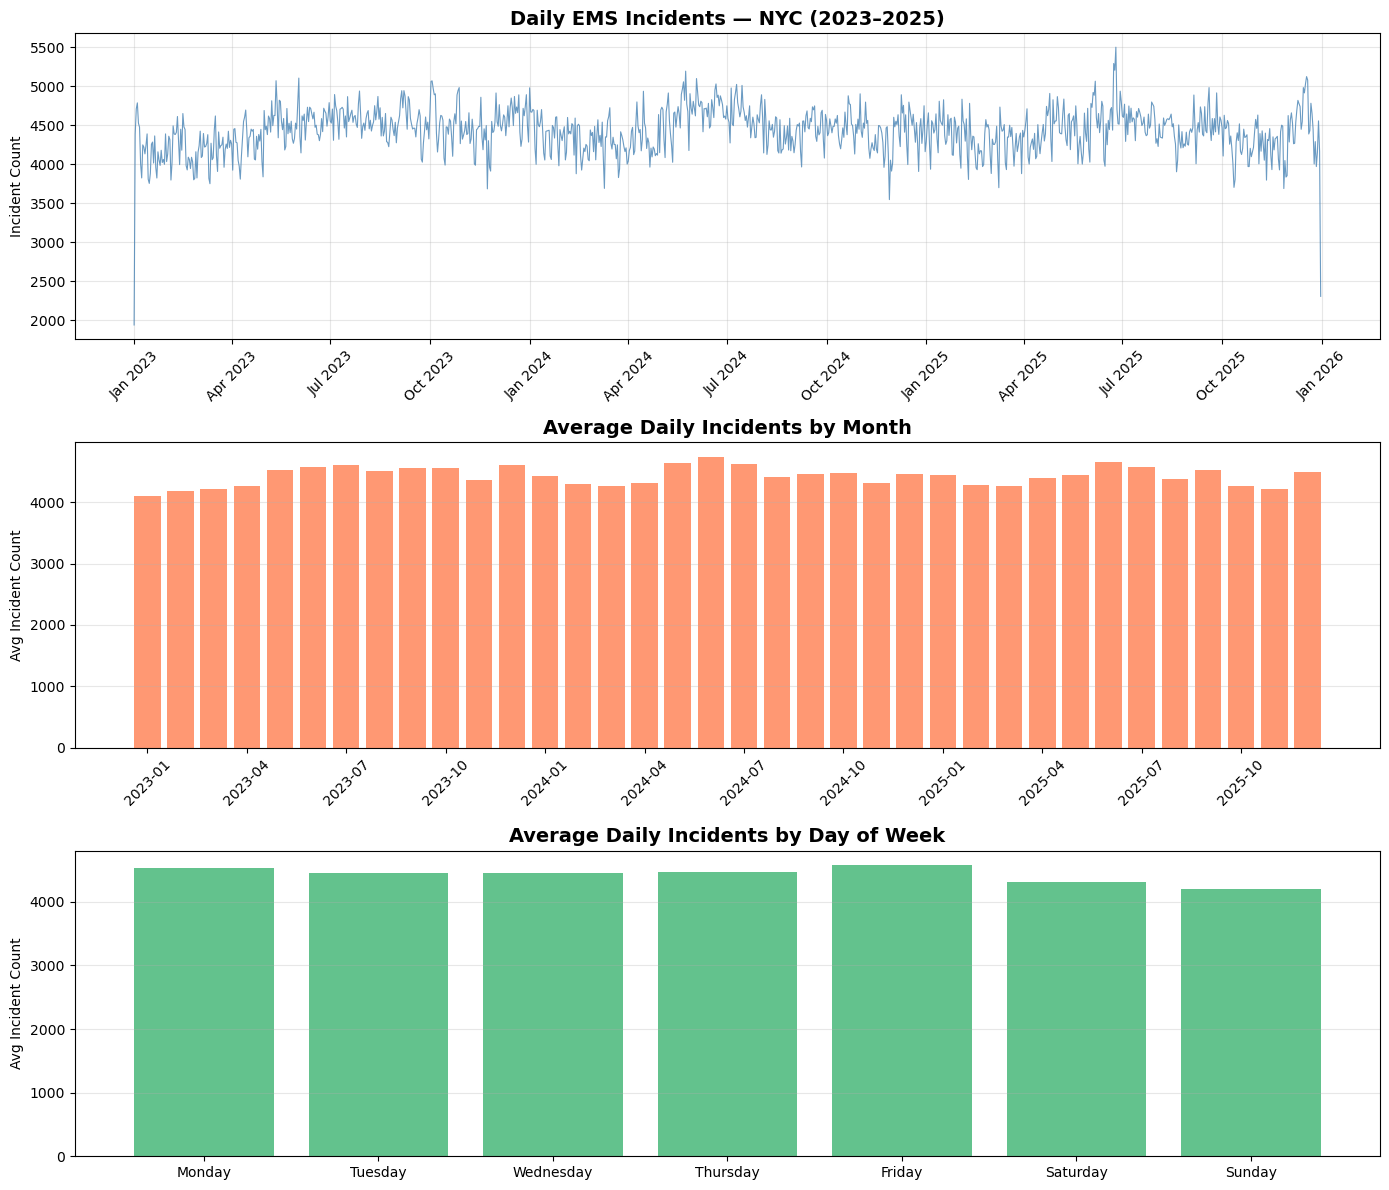

Plot saved!


In [11]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Plot 1 — Full daily trend
axes[0].plot(daily_df['DATE'], daily_df['INCIDENT_COUNT'], 
             color='steelblue', linewidth=0.8, alpha=0.8)
axes[0].set_title('Daily EMS Incidents — NYC (2023–2025)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Incident Count')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# Plot 2 — Monthly average
daily_df['MONTH'] = daily_df['DATE'].dt.to_period('M')
monthly = daily_df.groupby('MONTH')['INCIDENT_COUNT'].mean()
axes[1].bar(range(len(monthly)), monthly.values, color='coral', alpha=0.8)
axes[1].set_title('Average Daily Incidents by Month', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Avg Incident Count')
axes[1].set_xticks(range(0, len(monthly), 3))
axes[1].set_xticklabels([str(monthly.index[i]) for i in range(0, len(monthly), 3)], rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

# Plot 3 — Day of week pattern
daily_df['DOW'] = daily_df['DATE'].dt.day_name()
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_avg = daily_df.groupby('DOW')['INCIDENT_COUNT'].mean().reindex(dow_order)
axes[2].bar(dow_order, dow_avg.values, color='mediumseagreen', alpha=0.8)
axes[2].set_title('Average Daily Incidents by Day of Week', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Avg Incident Count')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('ems_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [12]:
# Remove partial days (Jan 1 2023 and Jan 1 2026 if present)
daily_df = daily_df[daily_df['INCIDENT_COUNT'] > 3000].reset_index(drop=True)

print("Shape after cleaning:", daily_df.shape)
print("Date range:", daily_df['DATE'].min(), "to", daily_df['DATE'].max())
print("Min incidents:", daily_df['INCIDENT_COUNT'].min())

Shape after cleaning: (1094, 4)
Date range: 2023-01-02 00:00:00 to 2025-12-30 00:00:00
Min incidents: 3547


In [13]:
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

def adf_test(series, name):
    result = adfuller(series, autolag='AIC')
    print(f'=== ADF Test: {name} ===')
    print(f'ADF Statistic  : {result[0]:.4f}')
    print(f'p-value        : {result[1]:.4f}')
    print(f'Critical Values:')
    for key, val in result[4].items():
        print(f'   {key}: {val:.4f}')
    if result[1] <= 0.05:
        print('✅ STATIONARY (p <= 0.05) — no differencing needed')
    else:
        print('❌ NON-STATIONARY (p > 0.05) — differencing required')
    print()

# Test original series
adf_test(daily_df['INCIDENT_COUNT'], 'Daily EMS Incidents')

# Test first difference just for comparison
adf_test(daily_df['INCIDENT_COUNT'].diff().dropna(), 'First Difference')

=== ADF Test: Daily EMS Incidents ===
ADF Statistic  : -4.0981
p-value        : 0.0010
Critical Values:
   1%: -3.4365
   5%: -2.8642
   10%: -2.5682
✅ STATIONARY (p <= 0.05) — no differencing needed

=== ADF Test: First Difference ===
ADF Statistic  : -10.4979
p-value        : 0.0000
Critical Values:
   1%: -3.4365
   5%: -2.8642
   10%: -2.5682
✅ STATIONARY (p <= 0.05) — no differencing needed



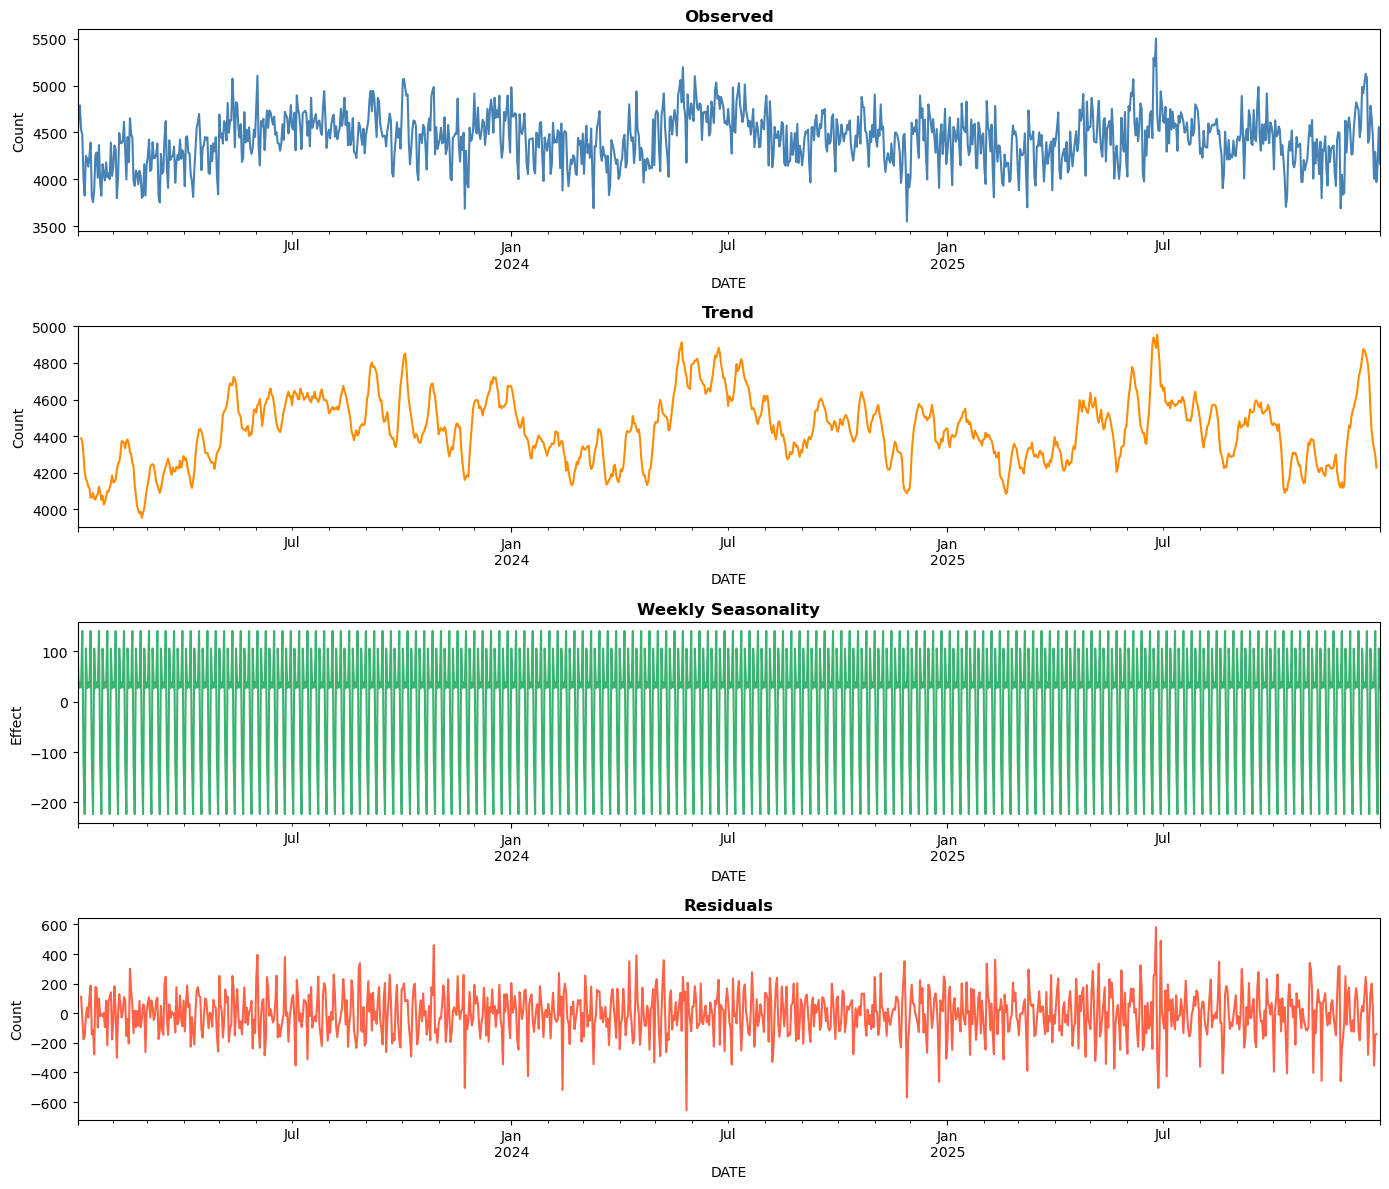

Decomposition saved!


In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Set DATE as index for decomposition
decomp_df = daily_df.set_index('DATE')['INCIDENT_COUNT']

# Decompose — period=7 for weekly seasonality
decomposition = seasonal_decompose(decomp_df, model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))

decomposition.observed.plot(ax=axes[0], color='steelblue')
axes[0].set_title('Observed', fontweight='bold')
axes[0].set_ylabel('Count')

decomposition.trend.plot(ax=axes[1], color='darkorange')
axes[1].set_title('Trend', fontweight='bold')
axes[1].set_ylabel('Count')

decomposition.seasonal.plot(ax=axes[2], color='mediumseagreen')
axes[2].set_title('Weekly Seasonality', fontweight='bold')
axes[2].set_ylabel('Effect')

decomposition.resid.plot(ax=axes[3], color='tomato')
axes[3].set_title('Residuals', fontweight='bold')
axes[3].set_ylabel('Count')

plt.tight_layout()
plt.savefig('ems_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Decomposition saved!")

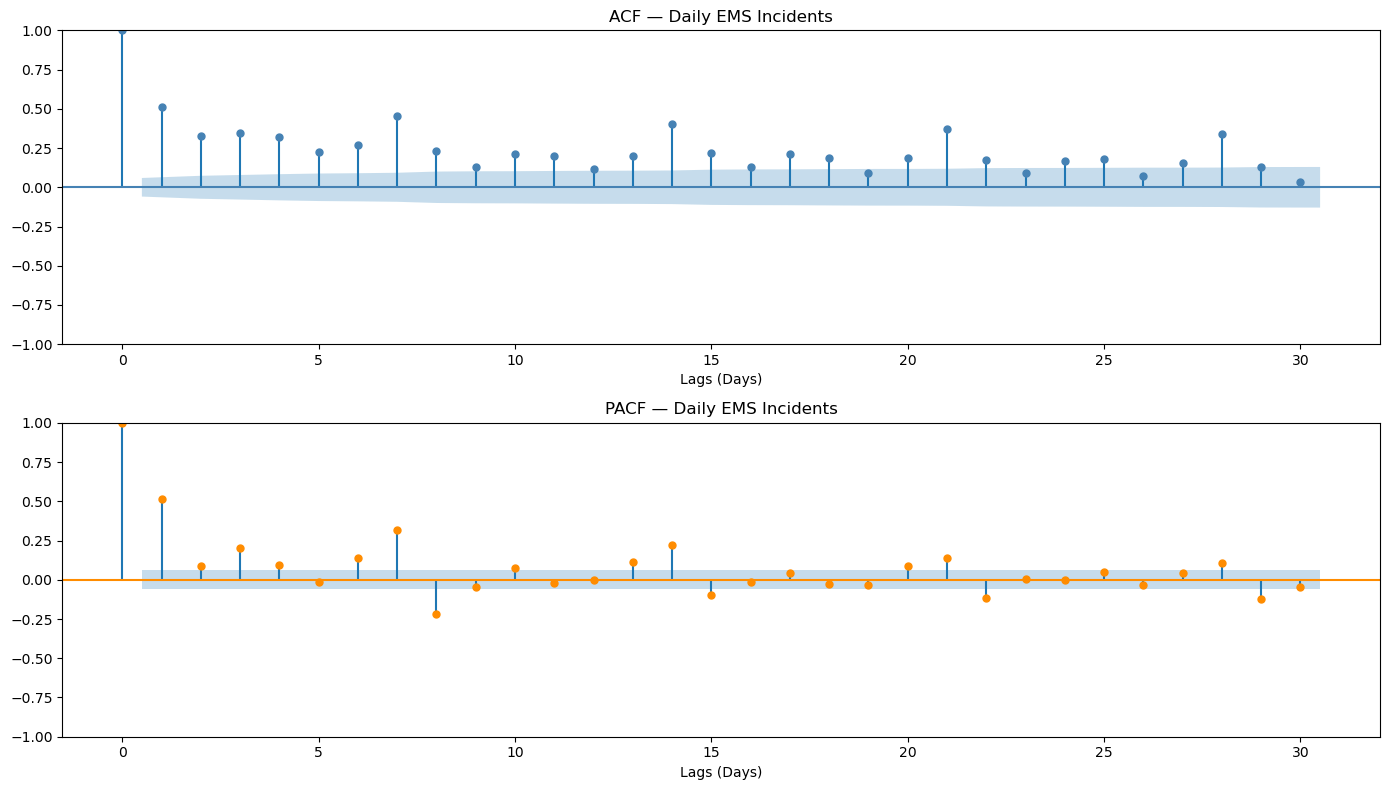

ACF/PACF saved!


In [15]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(daily_df['INCIDENT_COUNT'], lags=30, ax=axes[0], 
         color='steelblue', title='ACF — Daily EMS Incidents')
axes[0].set_xlabel('Lags (Days)')

plot_pacf(daily_df['INCIDENT_COUNT'], lags=30, ax=axes[1], 
          color='darkorange', title='PACF — Daily EMS Incidents')
axes[1].set_xlabel('Lags (Days)')

plt.tight_layout()
plt.savefig('ems_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print("ACF/PACF saved!")

In [16]:
# Train/Test split — last 90 days as test set
train = daily_df[:-90].copy()
test = daily_df[-90:].copy()

print(f"Training set: {train['DATE'].min().date()} to {train['DATE'].max().date()} ({len(train)} days)")
print(f"Testing set : {test['DATE'].min().date()} to {test['DATE'].max().date()} ({len(test)} days)")

# Baseline model — 7-day rolling mean (naive forecast)
train['ROLLING_MEAN'] = train['INCIDENT_COUNT'].rolling(window=7).mean()
last_7_avg = train['INCIDENT_COUNT'].tail(7).mean()
test['BASELINE'] = last_7_avg

# Baseline metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

baseline_mae = mean_absolute_error(test['INCIDENT_COUNT'], test['BASELINE'])
baseline_rmse = np.sqrt(mean_squared_error(test['INCIDENT_COUNT'], test['BASELINE']))
baseline_mape = np.mean(np.abs((test['INCIDENT_COUNT'] - test['BASELINE']) / test['INCIDENT_COUNT'])) * 100

print(f"\n=== Baseline Model (7-day Rolling Mean) ===")
print(f"MAE  : {baseline_mae:.2f}")
print(f"RMSE : {baseline_rmse:.2f}")
print(f"MAPE : {baseline_mape:.2f}%")

Training set: 2023-01-02 to 2025-10-01 (1004 days)
Testing set : 2025-10-02 to 2025-12-30 (90 days)

=== Baseline Model (7-day Rolling Mean) ===
MAE  : 294.79
RMSE : 364.17
MAPE : 7.05%


In [17]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA(1,0,1) based on ACF/PACF analysis
print("Fitting ARIMA(1,0,1)... please wait")

arima_model = ARIMA(train['INCIDENT_COUNT'], order=(1, 0, 1))
arima_result = arima_model.fit()

# Forecast on test set (90 days)
arima_forecast = arima_result.forecast(steps=90)
test['ARIMA'] = arima_forecast.values

# ARIMA metrics
arima_mae = mean_absolute_error(test['INCIDENT_COUNT'], test['ARIMA'])
arima_rmse = np.sqrt(mean_squared_error(test['INCIDENT_COUNT'], test['ARIMA']))
arima_mape = np.mean(np.abs((test['INCIDENT_COUNT'] - test['ARIMA']) / test['INCIDENT_COUNT'])) * 100

print(f"\n=== ARIMA(1,0,1) ===")
print(f"MAE  : {arima_mae:.2f}")
print(f"RMSE : {arima_rmse:.2f}")
print(f"MAPE : {arima_mape:.2f}%")

# Compare with baseline
print(f"\n=== vs Baseline ===")
print(f"MAE  improvement: {baseline_mae - arima_mae:.2f}")
print(f"RMSE improvement: {baseline_rmse - arima_rmse:.2f}")

Fitting ARIMA(1,0,1)... please wait

=== ARIMA(1,0,1) ===
MAE  : 246.88
RMSE : 317.10
MAPE : 5.84%

=== vs Baseline ===
MAE  improvement: 47.91
RMSE improvement: 47.07


In [18]:
# Install prophet if not already installed
import subprocess
subprocess.run(['pip', 'install', 'prophet', '--quiet'])

CompletedProcess(args=['pip', 'install', 'prophet', '--quiet'], returncode=0)

In [19]:
from prophet import Prophet

# Prophet requires columns named 'ds' and 'y'
train_prophet = train[['DATE', 'INCIDENT_COUNT']].rename(
    columns={'DATE': 'ds', 'INCIDENT_COUNT': 'y'})

# Fit Prophet with weekly + yearly seasonality and holidays
m = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='additive'
)

# Add US holidays — crucial for EMS data
m.add_country_holidays(country_name='US')

print("Fitting Prophet... please wait")
m.fit(train_prophet)

# Forecast 90 days
future = m.make_future_dataframe(periods=90)
forecast = m.predict(future)

# Extract test period predictions
prophet_pred = forecast[['ds', 'yhat']].tail(90)
test['PROPHET'] = prophet_pred['yhat'].values

# Prophet metrics
prophet_mae = mean_absolute_error(test['INCIDENT_COUNT'], test['PROPHET'])
prophet_rmse = np.sqrt(mean_squared_error(test['INCIDENT_COUNT'], test['PROPHET']))
prophet_mape = np.mean(np.abs((test['INCIDENT_COUNT'] - test['PROPHET']) / test['INCIDENT_COUNT'])) * 100

print(f"\n=== Prophet ===")
print(f"MAE  : {prophet_mae:.2f}")
print(f"RMSE : {prophet_rmse:.2f}")
print(f"MAPE : {prophet_mape:.2f}%")

print(f"\n=== vs ARIMA ===")
print(f"MAE  improvement: {arima_mae - prophet_mae:.2f}")
print(f"RMSE improvement: {arima_rmse - prophet_rmse:.2f}")

18:05:25 - cmdstanpy - INFO - Chain [1] start processing


Fitting Prophet... please wait


18:05:26 - cmdstanpy - INFO - Chain [1] done processing



=== Prophet ===
MAE  : 185.82
RMSE : 231.92
MAPE : 4.32%

=== vs ARIMA ===
MAE  improvement: 61.06
RMSE improvement: 85.19


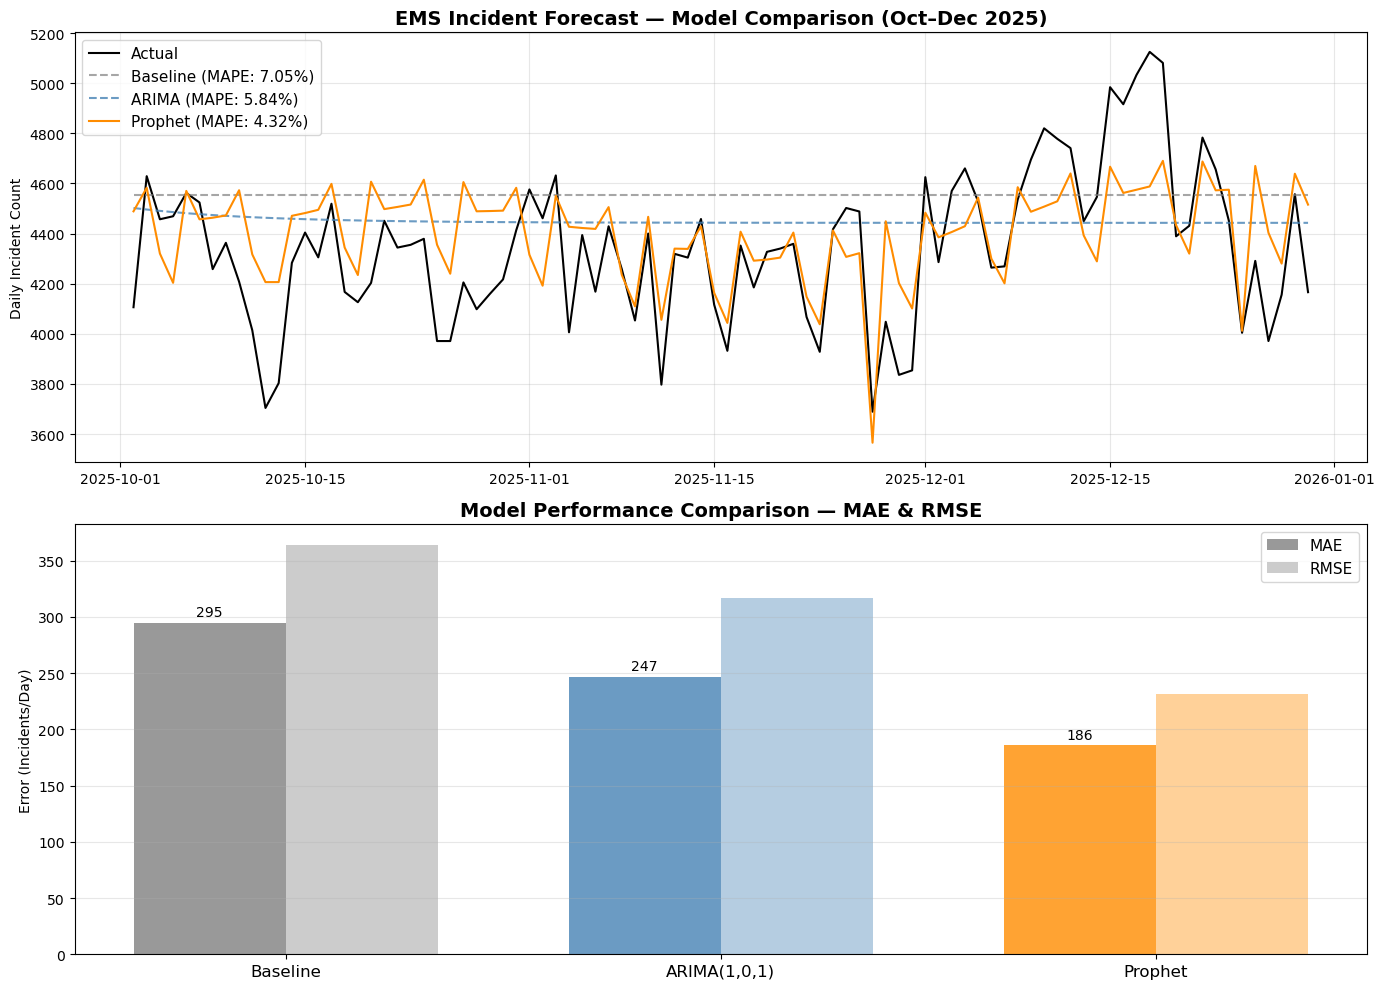

Comparison chart saved!


In [20]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1 — Forecast comparison
axes[0].plot(test['DATE'], test['INCIDENT_COUNT'], 
             label='Actual', color='black', linewidth=1.5)
axes[0].plot(test['DATE'], test['BASELINE'], 
             label=f'Baseline (MAPE: 7.05%)', color='gray', 
             linestyle='--', alpha=0.7)
axes[0].plot(test['DATE'], test['ARIMA'], 
             label=f'ARIMA (MAPE: 5.84%)', color='steelblue', 
             linestyle='--', alpha=0.8)
axes[0].plot(test['DATE'], test['PROPHET'], 
             label=f'Prophet (MAPE: 4.32%)', color='darkorange', 
             linewidth=1.5)
axes[0].set_title('EMS Incident Forecast — Model Comparison (Oct–Dec 2025)', 
                  fontsize=14, fontweight='bold')
axes[0].set_ylabel('Daily Incident Count')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2 — Metrics bar chart
models = ['Baseline', 'ARIMA(1,0,1)', 'Prophet']
maes = [baseline_mae, arima_mae, prophet_mae]
rmses = [baseline_rmse, arima_rmse, prophet_rmse]

x = np.arange(len(models))
width = 0.35
bars1 = axes[1].bar(x - width/2, maes, width, label='MAE', color=['gray','steelblue','darkorange'], alpha=0.8)
bars2 = axes[1].bar(x + width/2, rmses, width, label='RMSE', color=['gray','steelblue','darkorange'], alpha=0.4)

axes[1].set_title('Model Performance Comparison — MAE & RMSE', 
                  fontsize=14, fontweight='bold')
axes[1].set_ylabel('Error (Incidents/Day)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 3,
                f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('ems_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Comparison chart saved!")

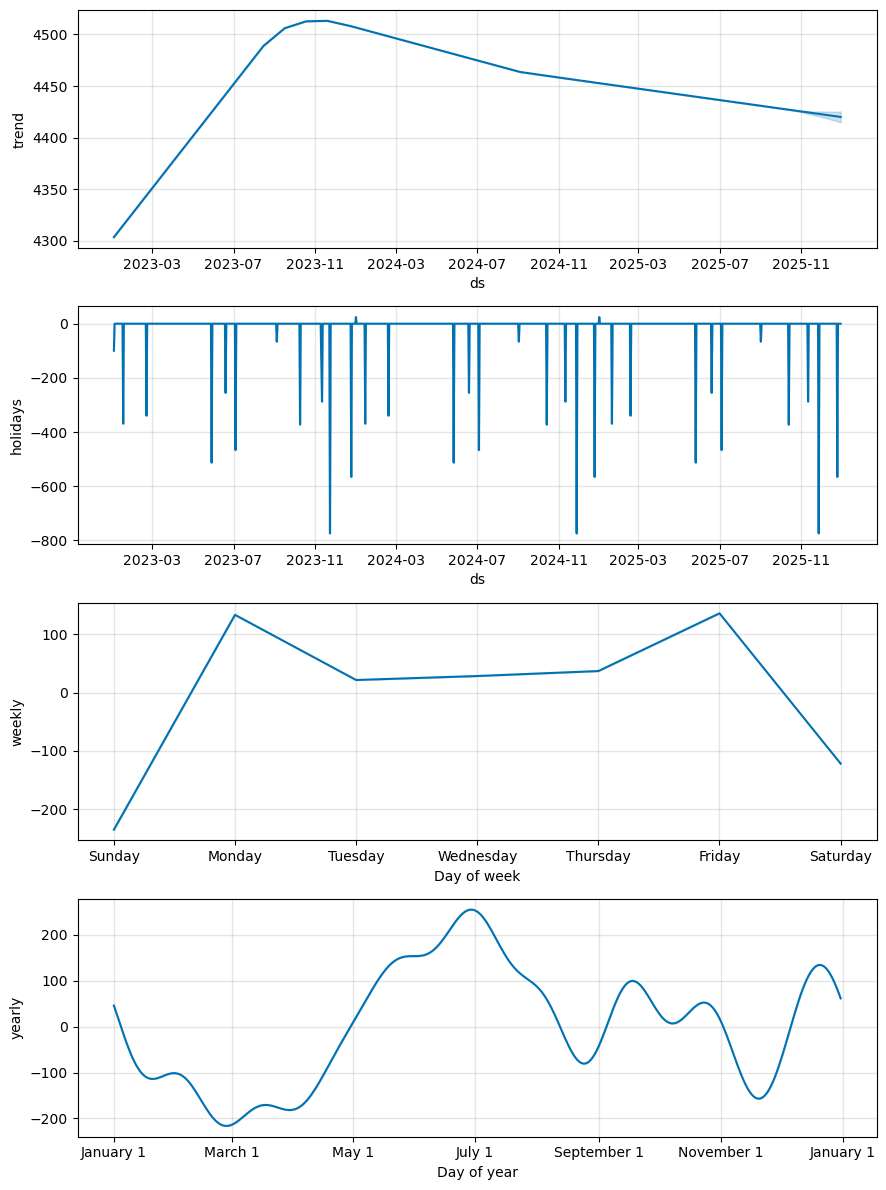

In [21]:
fig = m.plot_components(forecast)
plt.savefig('prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()

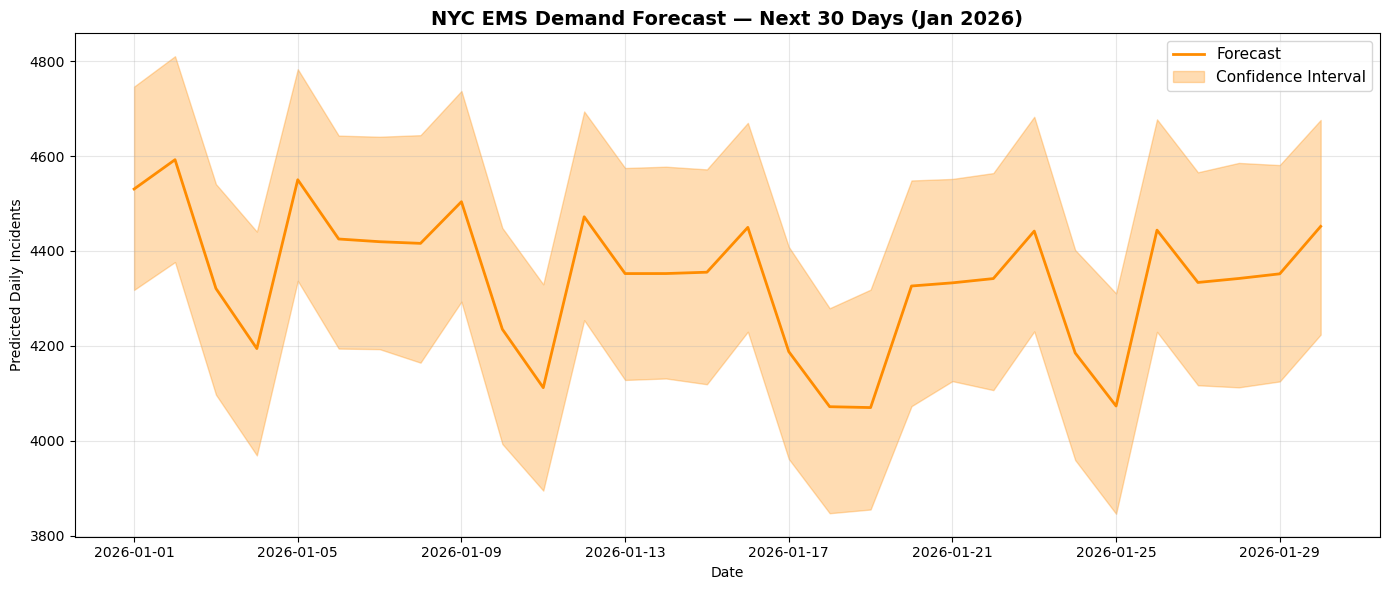


30-Day NYC EMS Forecast (Jan 2026):
        ds   yhat  yhat_lower  yhat_upper
2026-01-01 4531.0      4318.0      4747.0
2026-01-02 4592.0      4377.0      4811.0
2026-01-03 4321.0      4097.0      4541.0
2026-01-04 4194.0      3969.0      4441.0
2026-01-05 4550.0      4337.0      4783.0
2026-01-06 4425.0      4194.0      4643.0
2026-01-07 4420.0      4193.0      4641.0
2026-01-08 4416.0      4165.0      4644.0
2026-01-09 4504.0      4293.0      4737.0
2026-01-10 4235.0      3993.0      4449.0
2026-01-11 4112.0      3895.0      4330.0
2026-01-12 4472.0      4254.0      4694.0
2026-01-13 4352.0      4128.0      4575.0
2026-01-14 4352.0      4131.0      4578.0
2026-01-15 4355.0      4119.0      4572.0
2026-01-16 4450.0      4230.0      4670.0
2026-01-17 4188.0      3962.0      4409.0
2026-01-18 4072.0      3847.0      4279.0
2026-01-19 4070.0      3855.0      4318.0
2026-01-20 4326.0      4073.0      4549.0
2026-01-21 4333.0      4126.0      4552.0
2026-01-22 4342.0      4107.0      4564

In [23]:
# Fix — explicitly define future dates
future_dates = pd.date_range(start='2026-01-01', periods=30, freq='D')
future_df = pd.DataFrame({'ds': future_dates})

# Predict
forecast_future = m.predict(future_df)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(forecast_future['ds'], forecast_future['yhat'], 
        color='darkorange', linewidth=2, label='Forecast')
ax.fill_between(forecast_future['ds'], 
                forecast_future['yhat_lower'], 
                forecast_future['yhat_upper'],
                alpha=0.3, color='darkorange', label='Confidence Interval')
ax.set_title('NYC EMS Demand Forecast — Next 30 Days (Jan 2026)', 
             fontsize=14, fontweight='bold')
ax.set_ylabel('Predicted Daily Incidents')
ax.set_xlabel('Date')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ems_future_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n30-Day NYC EMS Forecast (Jan 2026):")
print(forecast_future[['ds','yhat','yhat_lower','yhat_upper']].round(0).to_string(index=False))